In [66]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay, accuracy_score,
    classification_report, f1_score, roc_auc_score,)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

In [67]:
df = pd.read_excel("data/indian_liver_patient.xlsx")

In [68]:
print(df.shape)
df.info()

(583, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    object 
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Dataset                     583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


In [69]:
# Missing values 
print(df.isnull().sum()[df.isnull().sum() > 0])

# Duplicate rows
print(df.duplicated().sum())

# Target balance 
print(df["Dataset"].value_counts(normalize=True))

Albumin_and_Globulin_Ratio    4
dtype: int64
13
Dataset
1    0.713551
2    0.286449
Name: proportion, dtype: float64


In [70]:
df = df.drop_duplicates()

In [71]:
num_cols = df.select_dtypes(include=[np.number]).columns.drop("Dataset").tolist()
#skewness
print(df[num_cols].skew().sort_values(ascending=False))

Aspartate_Aminotransferase    10.559418
Alamine_Aminotransferase       6.695054
Total_Bilirubin                4.869459
Alkaline_Phosphotase           3.728405
Direct_Bilirubin               3.187685
Albumin_and_Globulin_Ratio     1.001294
Age                           -0.046597
Albumin                       -0.060829
Total_Protiens                -0.310929
dtype: float64


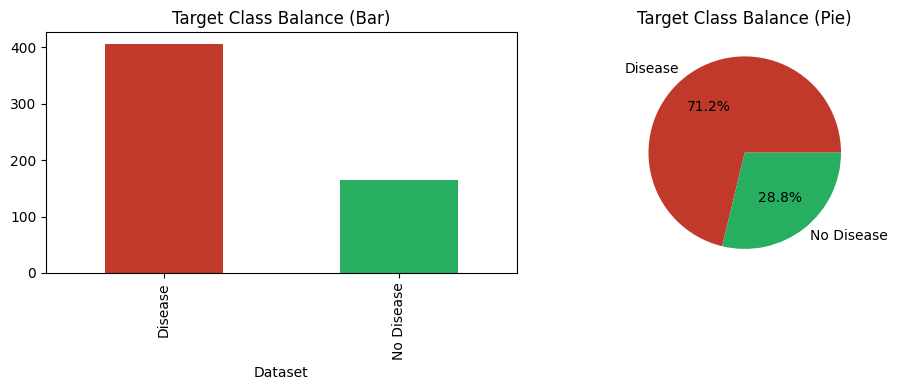

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df["Dataset"].map({1: "Disease", 2: "No Disease"}).value_counts().plot(
    kind="bar", color=["#c0392b", "#27ae60"], ax=axes[0]
)
axes[0].set_ylabel("")
axes[0].set_title("Target Class Balance (Bar)")

df["Dataset"].map({1: "Disease", 2: "No Disease"}).value_counts().plot(
    kind="pie", autopct="%1.1f%%", colors=["#c0392b", "#27ae60"], ax=axes[1]
)
axes[1].set_ylabel("")
axes[1].set_title("Target Class Balance (Pie)")
plt.tight_layout()
plt.show()

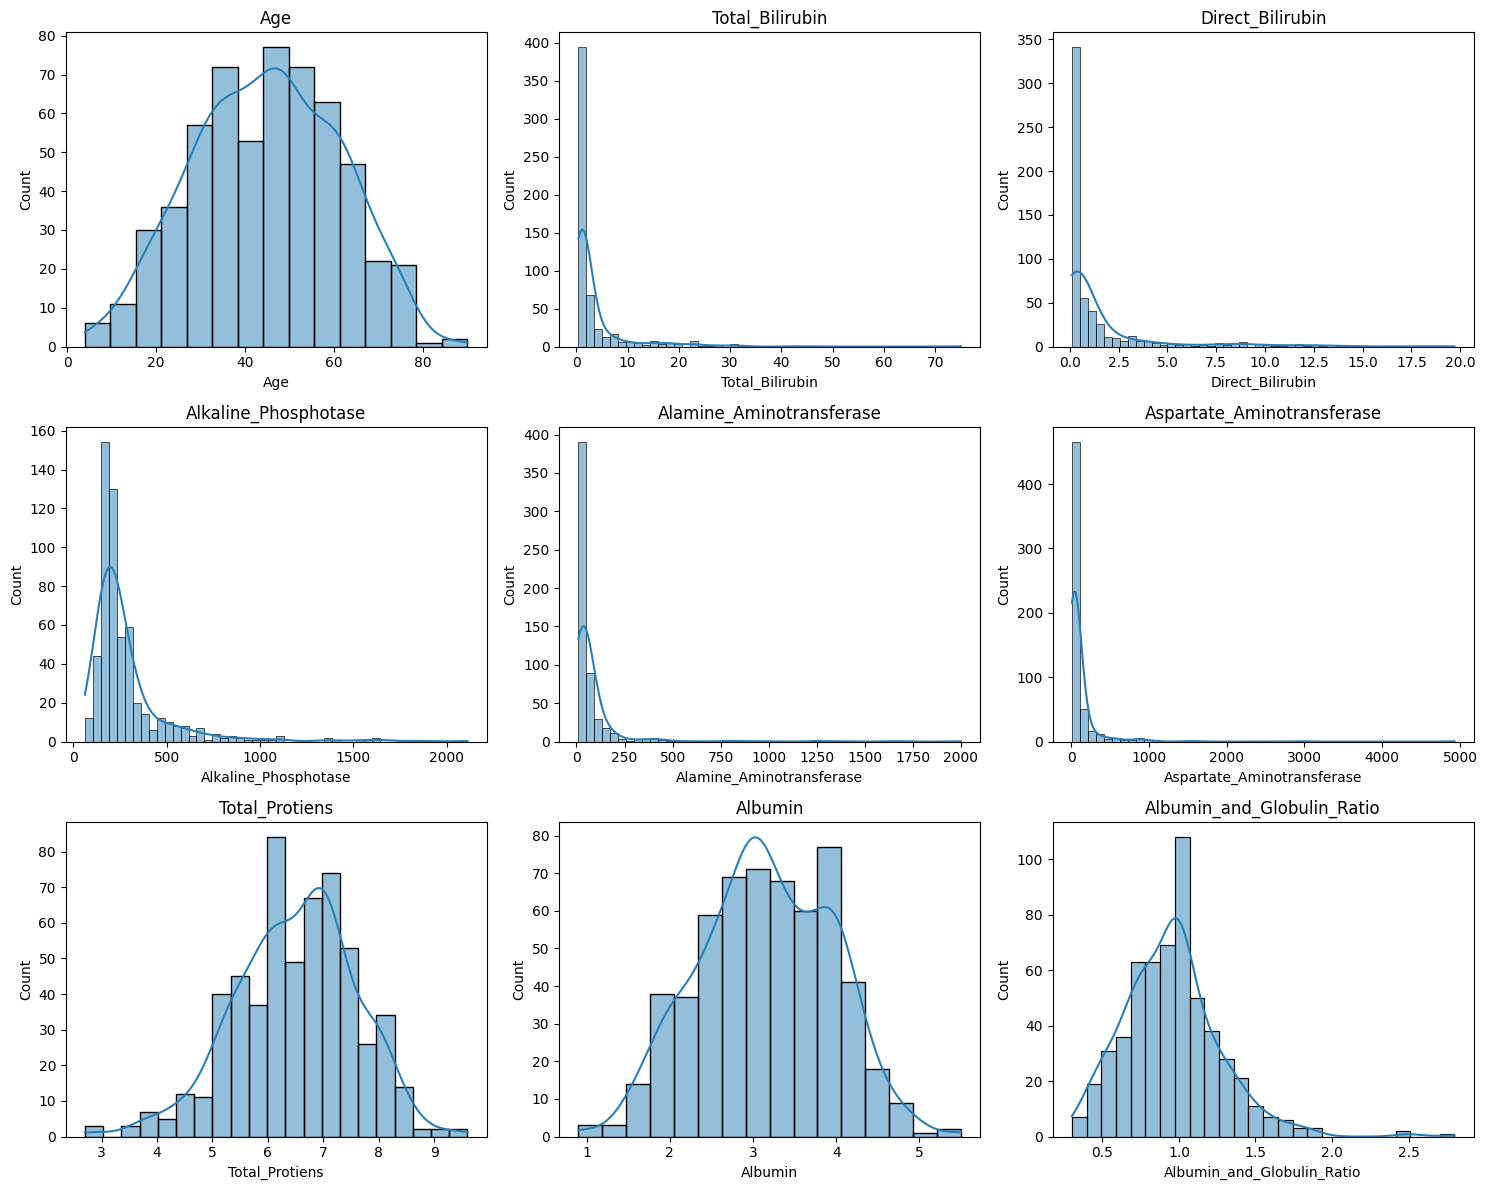

In [73]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="#2980b9")
    ax.set_title(col)
plt.tight_layout()
plt.show()

Boxplot

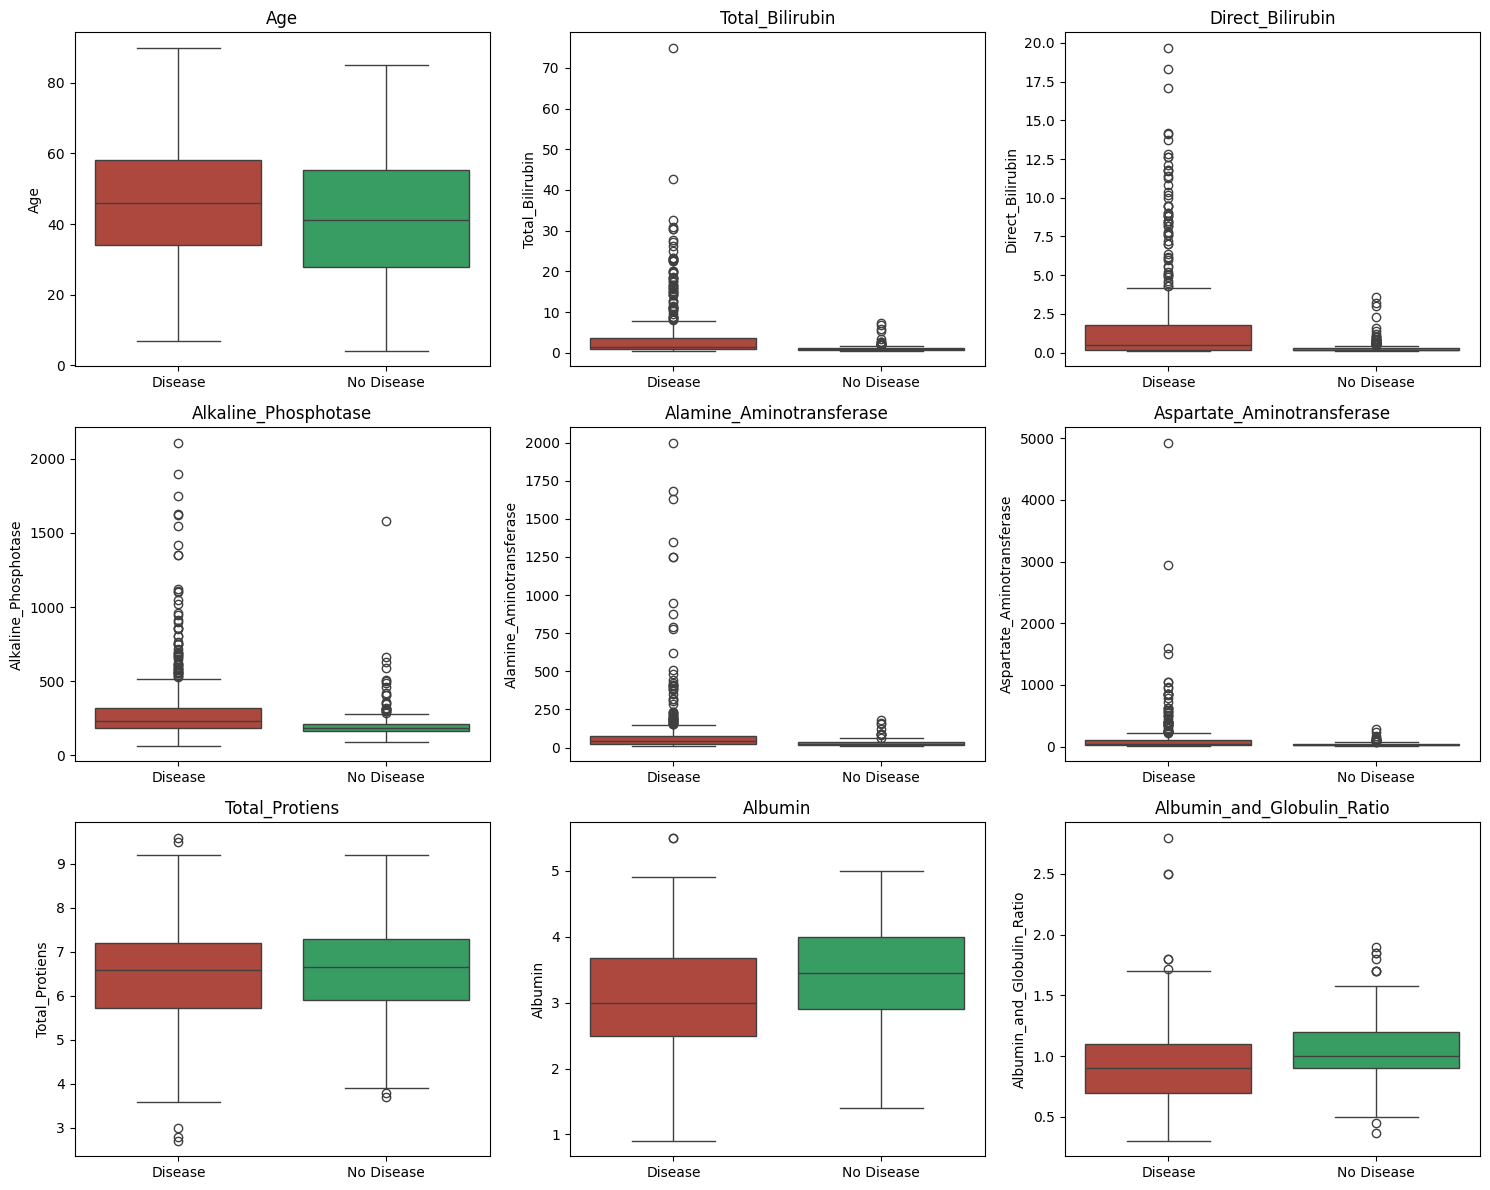

In [74]:
target_labels = df["Dataset"].map({1: "Disease", 2: "No Disease"})

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(x=target_labels, y=df[col], hue=target_labels, ax=ax,
                palette={"No Disease": "#27ae60", "Disease": "#c0392b"}, legend=False)
    ax.set_xlabel("")
    ax.set_title(col)
plt.tight_layout()
plt.show()

Correlation Heatmap

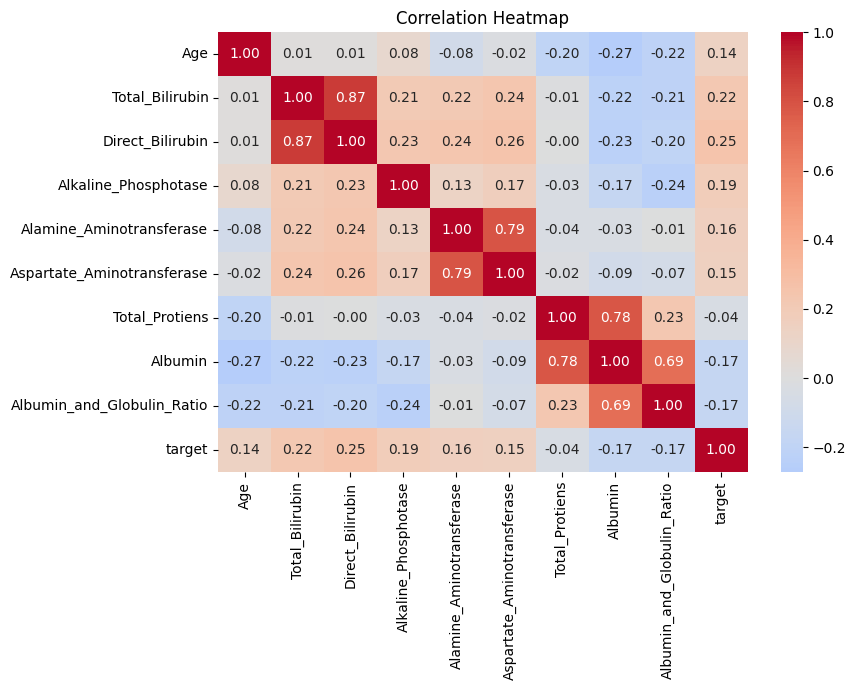

In [75]:
corr = df[num_cols].assign(target=(df["Dataset"] == 1).astype(int)).corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.show()


In [76]:
missing_ratio = df["Albumin_and_Globulin_Ratio"].isna()
globulin = df["Total_Protiens"] - df["Albumin"]
df.loc[missing_ratio, "Albumin_and_Globulin_Ratio"] = (df["Albumin"] / globulin)[missing_ratio]

In [77]:
df['Gender'].unique()

array(['Female', 'Male'], dtype=object)

In [78]:
df["Gender_Male"] = (df["Gender"] == "Male").astype(int)
df = df.drop(columns=["Gender"])

In [79]:
df.head(10)

,Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset,Gender_Male
0,65,0.7,0.1,187,16,18,6.8,3.3,0.90,1,0
1,62,10.9,5.5,699,64,100,7.5,3.2,0.74,1,1
2,62,7.3,4.1,490,60,68,7.0,3.3,0.89,1,1
3,58,1.0,0.4,182,14,20,6.8,3.4,1.00,1,1
4,72,3.9,2.0,195,27,59,7.3,2.4,0.40,1,1
5,46,1.8,0.7,208,19,14,7.6,4.4,1.30,1,1
6,26,0.9,0.2,154,16,12,7.0,3.5,1.00,1,0
7,29,0.9,0.3,202,14,11,6.7,3.6,1.10,1,0
8,17,0.9,0.3,202,22,19,7.4,4.1,1.20,2,1
9,55,0.7,0.2,290,53,58,6.8,3.4,1.00,1,1


In [80]:
skewed_cols = [
    "Total_Bilirubin", "Direct_Bilirubin", "Alkaline_Phosphotase",
    "Alamine_Aminotransferase", "Aspartate_Aminotransferase",
]

for col in skewed_cols:
    df[col] = np.log1p(df[col])

In [81]:
print(df[num_cols].skew().sort_values(ascending=False))

Total_Bilirubin               1.731438
Direct_Bilirubin              1.689599
Alamine_Aminotransferase      1.470664
Alkaline_Phosphotase          1.326397
Aspartate_Aminotransferase    1.246183
Albumin_and_Globulin_Ratio    0.988297
Age                          -0.046597
Albumin                      -0.060829
Total_Protiens               -0.310929
dtype: float64


In [82]:
df["Dataset"] = df["Dataset"].replace({2: 0})

In [83]:
df.head(10)

,Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset,Gender_Male
0,65,0.530628,0.095310,5.236442,2.833213,2.944439,6.8,3.3,0.90,1,0
1,62,2.476538,1.871802,6.551080,4.174387,4.615121,7.5,3.2,0.74,1,1
2,62,2.116256,1.629241,6.196444,4.110874,4.234107,7.0,3.3,0.89,1,1
3,58,0.693147,0.336472,5.209486,2.708050,3.044522,6.8,3.4,1.00,1,1
4,72,1.589235,1.098612,5.278115,3.332205,4.094345,7.3,2.4,0.40,1,1
5,46,1.029619,0.530628,5.342334,2.995732,2.708050,7.6,4.4,1.30,1,1
6,26,0.641854,0.182322,5.043425,2.833213,2.564949,7.0,3.5,1.00,1,0
7,29,0.641854,0.262364,5.313206,2.708050,2.484907,6.7,3.6,1.10,1,0
8,17,0.641854,0.262364,5.313206,3.135494,2.995732,7.4,4.1,1.20,0,1
9,55,0.530628,0.182322,5.673323,3.988984,4.077537,6.8,3.4,1.00,1,1


Pipeline

In [84]:
X = df.drop(columns=["Dataset"])
y = df["Dataset"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(X_train.shape, X_test.shape)

(456, 10) (114, 10)


In [85]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled = scaler.transform(X_test)          

Cross-validation evaluation

In [86]:
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()  # for XGBoost

models = {
    "LogisticRegression": LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=42
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=300, max_depth=6, min_samples_leaf=5,
        class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=pos_weight, eval_metric="logloss",
        random_state=42, n_jobs=-1
    ),
}

In [87]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["roc_auc", "f1", "accuracy"]

cv_results = {}
print(f"{'Model':<20}{'ROC-AUC':>12}{'F1':>12}{'Accuracy':>12}")
print("-" * 56)
for name, clf in models.items():
    scores = cross_validate(clf, X_train_scaled, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:<20}{scores['test_roc_auc'].mean():>12.4f}"
          f"{scores['test_f1'].mean():>12.4f}{scores['test_accuracy'].mean():>12.4f}")

best_name = max(cv_results, key=lambda n: cv_results[n]["test_f1"].mean())
print(f"\nBest model by mean CV F1: {best_name}")

Model                    ROC-AUC          F1    Accuracy
--------------------------------------------------------
LogisticRegression        0.7172      0.7008      0.6403
RandomForest              0.7189      0.7445      0.6666
XGBoost                   0.6854      0.7601      0.6667

Best model by mean CV F1: XGBoost


In [63]:
best_model = models[best_name]
best_model.fit(X_train_scaled, y_train)

y_pred = best_model.predict(X_test_scaled)
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}")
print(f"F1       : {f1_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["No Disease", "Disease"]))

Accuracy : 0.6842
ROC-AUC  : 0.7333
F1       : 0.7907

              precision    recall  f1-score   support

  No Disease       0.43      0.30      0.36        33
     Disease       0.75      0.84      0.79        81

    accuracy                           0.68       114
   macro avg       0.59      0.57      0.57       114
weighted avg       0.66      0.68      0.67       114



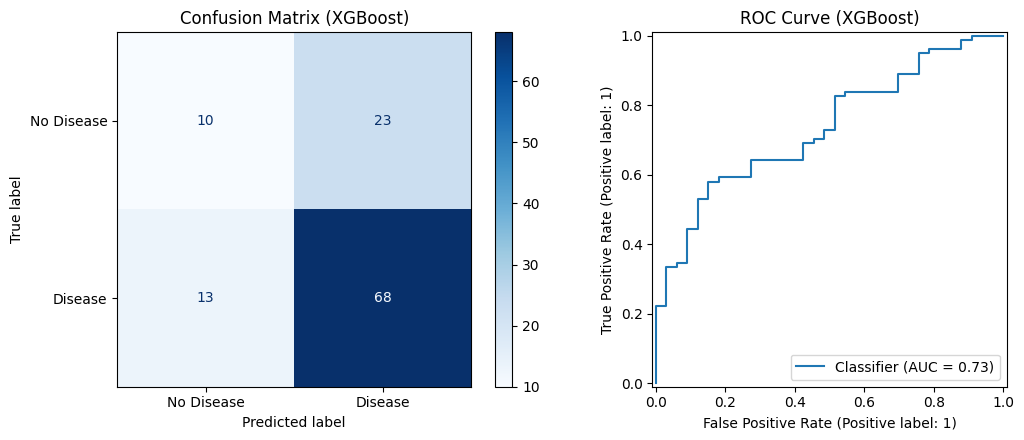

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["No Disease", "Disease"], cmap="Blues", ax=axes[0]
)
axes[0].set_title(f"Confusion Matrix ({best_name})")
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title(f"ROC Curve ({best_name})")
plt.tight_layout()
plt.show()

Saving Pipeline

In [89]:
liver_model = {
    "model": best_model,
    "model_name": best_name,
    "scaler": scaler,
    "feature_columns": list(X.columns),
    "skewed_cols": skewed_cols,
}
joblib.dump(liver_model, "liver_model.joblib")

['liver_model.joblib']